## 5.3 전이학습

### 5.3.1 특성 추출 기법

#### 데이터 준비

In [ ]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms # 데이터 전처리용 패키지
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving catanddog.zip to catanddog.zip


In [ ]:
 #catanddog 폴더 만들어 압축 해제
!unzip catanddog.zip -d catanddog/

Archive:  catanddog.zip
   creating: catanddog/test/
   creating: catanddog/test/Cat/
  inflating: catanddog/test/Cat/8100.jpg  
  inflating: catanddog/test/Cat/8101.jpg  
  inflating: catanddog/test/Cat/8102.jpg  
  inflating: catanddog/test/Cat/8103.jpg  
  inflating: catanddog/test/Cat/8104.jpg  
  inflating: catanddog/test/Cat/8105.jpg  
  inflating: catanddog/test/Cat/8106.jpg  
  inflating: catanddog/test/Cat/8107.jpg  
  inflating: catanddog/test/Cat/8108.jpg  
  inflating: catanddog/test/Cat/8109.jpg  
  inflating: catanddog/test/Cat/8110.jpg  
  inflating: catanddog/test/Cat/8111.jpg  
  inflating: catanddog/test/Cat/8112.jpg  
  inflating: catanddog/test/Cat/8113.jpg  
  inflating: catanddog/test/Cat/8114.jpg  
  inflating: catanddog/test/Cat/8115.jpg  
  inflating: catanddog/test/Cat/8116.jpg  
  inflating: catanddog/test/Cat/8117.jpg  
  inflating: catanddog/test/Cat/8118.jpg  
  inflating: catanddog/test/Cat/8119.jpg  
  inflating: catanddog/test/Cat/8120.jpg  
  inflating

In [ ]:
# 이미지 데이터 전처리
data_path = 'catanddog/train/'

# 이미지 데이터를 변환해 모델의 입력으로 사용할 수 있게 변환
transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)

# 앞에서 정의한 데이터셋(이미지 폴더)을 로더에 할당
# 한 번에 불러올 데이터양을 결정하는 배치 크기 지정
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


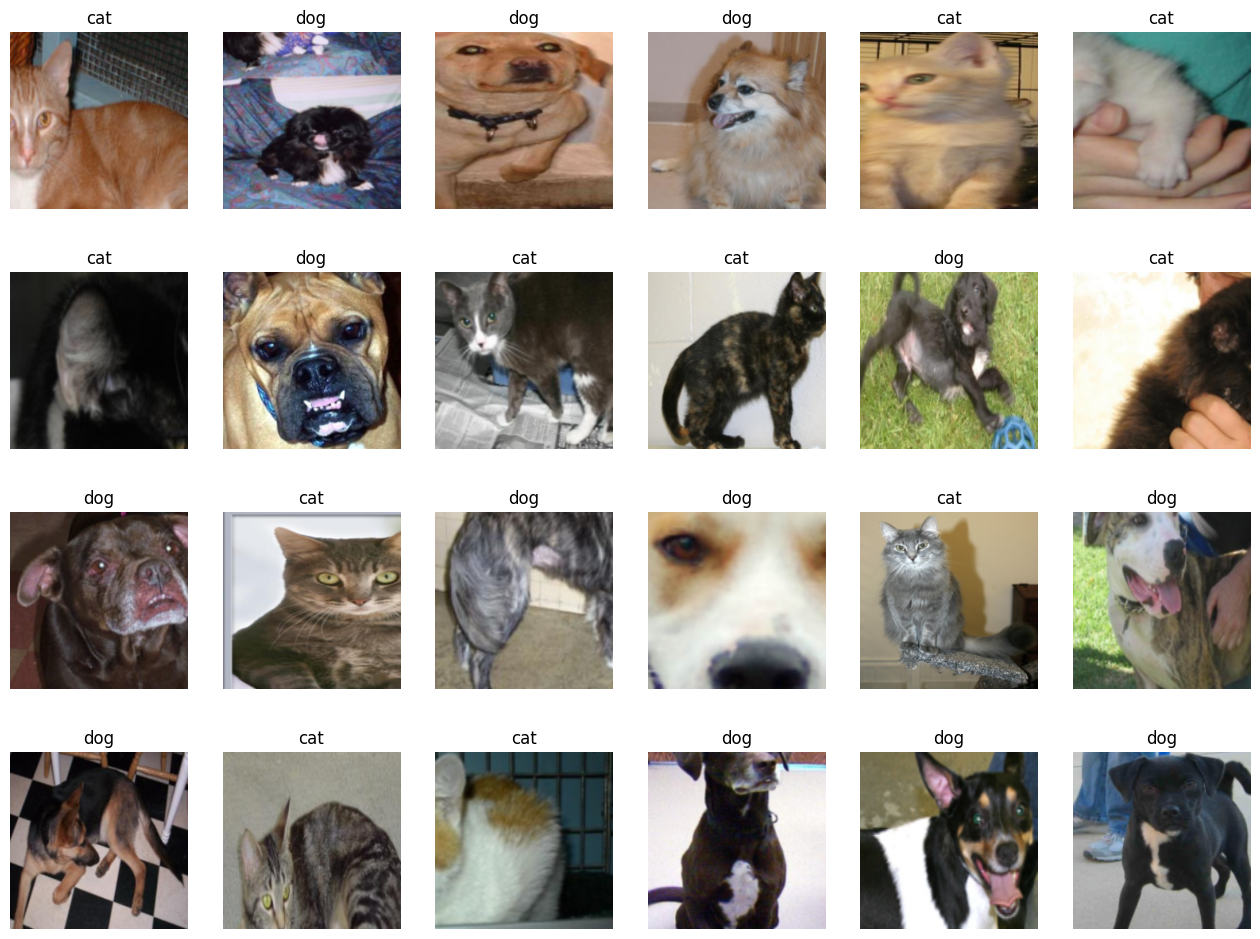

In [ ]:
# 불러온 이미지를 레이블 정보와 함께 출력
samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))

# 24개의 이미지 데이터 출력
for i in range(24):
    a = fig.add_subplot(4,6,i+1)
    a.set_title(classes[labels[i].item()])
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

.next() 함수를 교재에서 사용하라고 했는데,_MultiProcessingDataLoaderIter 객체에 해당 메서드가 없어서 오류가 발생함.
<br>
최신 파이썬/파이토치 버전에서는 iter(객체).next() 대신 `next(iter(객체))`를 사용하여 iterator에서 다음 항목을 가져와야 함!

**RESNET18** <br>
- 50개 계층으로 이루어진 CNN.
- ImageNet DB의 100만 개가 넘는 영상을 이용해  훈련된 신경망으로 **전이 학습**에 사용되도록 사준 훈련된 모델을 제공

In [ ]:
# download pre-trained model
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 325MB/s]


models.모델명(pretrained=True) : 사전 학습된 모델의 가중치 값을 사용

In [ ]:
# ResNet18의 학습곱층을 사용하되 파라미터에 대해서는 학습하지 않도록 고정
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      # 역전파 중 파라미터에 대한 변화 계산이 불필요함을 나타냄
      # 모델의 합성곱층과 풀링층을 고정하고 나머지를 학습
      param.set_parameter_requires_grad = False;

set_parameter_requires_grad(resnet18)

모델의 일부(합성곱층, 풀링층)를 고정하고 나머지를 학습하고자 할 때 **requires_grad=False**

In [ ]:
# 모델의 마지막 부분에 완전연결층 추가: 개와 고양이 클래스 분류하는 용도
resnet18.fc = nn.Linear(512, 2) # 2: 클래스가 두 개라는 의미

In [ ]:
# 모델의 파라미터값 확인
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[-0.0225,  0.0102,  0.0433,  ...,  0.0408,  0.0427,  0.0367],
        [ 0.0066,  0.0030,  0.0304,  ...,  0.0211, -0.0150, -0.0056]])
fc.bias tensor([-0.0159,  0.0291])


In [ ]:
# 모델 객체 생성
model = models.resnet18(pretrained = True)

for param in model.parameters():
    param.requires_grad = False # 학습 x: 합성곱층 가중치 고정

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters():
    param.requires_grad = True # 완전연결층은 학습

# 손실 함수 정의
optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

최하단에 fc층 추가됨.

#### 모델 학습

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        # 데이터로더에 전달된 데이터만큼 반복
        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad() # 기울기를 0으로 설정
            outputs = model(inputs) # 순전파
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            # 출력 결과와 레이블의 오차를 계산한 결과 누적해 저장
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # 평균 오차 및 평균 정확도
        epoch_loss = running_loss / len(dataloaders.dataset)
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('catanddog/', '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history, loss_history

In [ ]:
# 파라미터 학습 결과를 옵티마이저에 전달
params_to_update = []
for name,param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param) # 파라미터 학습 결과 저장
        print("\t",name)

# 학습 결과를 옵티마이저에 전달
optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [ ]:
# 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 손실 함수 지정
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.6121 Acc: 0.6779

Epoch 1/12
----------
Loss: 0.3927 Acc: 0.8416

Epoch 2/12
----------
Loss: 0.4062 Acc: 0.8078

Epoch 3/12
----------
Loss: 0.2604 Acc: 0.9143

Epoch 4/12
----------
Loss: 0.2815 Acc: 0.8857

Epoch 5/12
----------
Loss: 0.2375 Acc: 0.8987

Epoch 6/12
----------
Loss: 0.2252 Acc: 0.9195

Epoch 7/12
----------
Loss: 0.2160 Acc: 0.9273

Epoch 8/12
----------
Loss: 0.1934 Acc: 0.9247

Epoch 9/12
----------
Loss: 0.1755 Acc: 0.9506

Epoch 10/12
----------
Loss: 0.2239 Acc: 0.9143

Epoch 11/12
----------
Loss: 0.1899 Acc: 0.9195

Epoch 12/12
----------
Loss: 0.1683 Acc: 0.9455

Training complete in 6m 27s
Best Acc: 0.950649


### 테스트

In [ ]:
# 데스트 데이터 호출 및 전처리
test_path = 'catanddog/test/'

transform = transforms.Compose(
                [
                    transforms.Resize(224),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [ ]:
# 모델 평가 함수 정의
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('catanddog/' + '*.pth')
    saved_models.sort()
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)

            # 출력된 torch.max 값:
            preds[preds >= 0.5] = 1 # 정답
            preds[preds < 0.5] = 0 # 오답
            running_corrects += preds.eq(labels).int().sum()

        # 테스트 데이터의 정확도 계산
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history

In [ ]:
# 모델 평가 함수에 테스트 데이터 적용하여 성능 측정
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['catanddog/00.pth', 'catanddog/01.pth', 'catanddog/02.pth', 'catanddog/03.pth', 'catanddog/04.pth', 'catanddog/05.pth', 'catanddog/06.pth', 'catanddog/07.pth', 'catanddog/08.pth', 'catanddog/09.pth', 'catanddog/10.pth', 'catanddog/11.pth', 'catanddog/12.pth']
Loading model catanddog/00.pth
Acc: 0.9082

Loading model catanddog/01.pth
Acc: 0.8367

Loading model catanddog/02.pth
Acc: 0.8980

Loading model catanddog/03.pth
Acc: 0.9286

Loading model catanddog/04.pth
Acc: 0.9184

Loading model catanddog/05.pth
Acc: 0.9490

Loading model catanddog/06.pth
Acc: 0.9184

Loading model catanddog/07.pth
Acc: 0.9592

Loading model catanddog/08.pth
Acc: 0.9388

Loading model catanddog/09.pth
Acc: 0.9592

Loading model catanddog/10.pth
Acc: 0.9592

Loading model catanddog/11.pth
Acc: 0.9184

Loading model catanddog/12.pth
Acc: 0.9592

Validation complete in 1m 35s
Best Acc: 0.959184


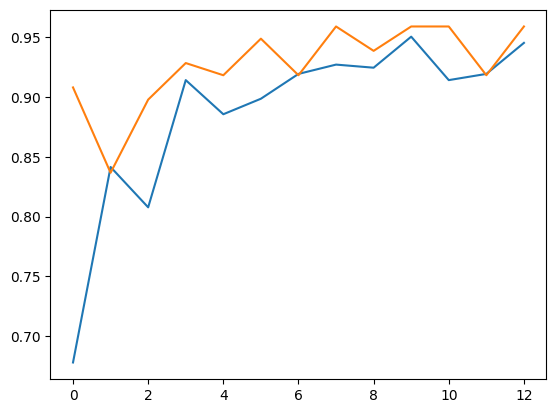

In [ ]:
plt.plot(train_acc_hist) # 훈련 데이터에 대한 정확도 (파랑)
plt.plot(val_acc_hist) # 테스트 데이터에 대한 정확도 (주황)
plt.show()

둘 다 에포크가 진행될수록 정확도가 높아지고 있음 → 더 많은 에포크 진행 시 정확도 100%에 수렴할 것.

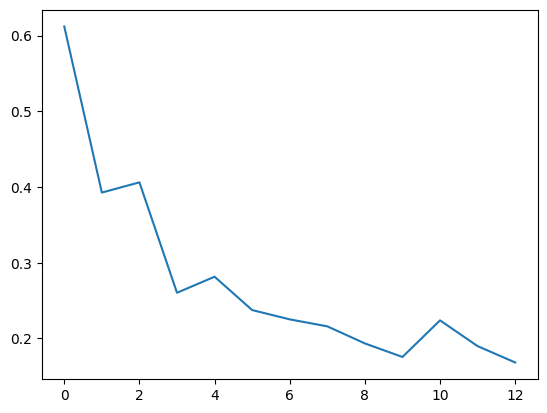

In [ ]:
# 훈련 데이터의 오차에 대한 그래프
plt.plot(train_loss_hist)
plt.show()

에포크가 진행될수록 오차가 낮아지고 있으므로 학습이 정상적으로 진행되고 있다는 것을 알 수 있음.

In [ ]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
    image=tensor.clone().detach().numpy()
    image=image.transpose(1,2,0)
    image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
    image=image.clip(0,1) # image 데이터를 0과 1 사이 값으로 제한
    return image

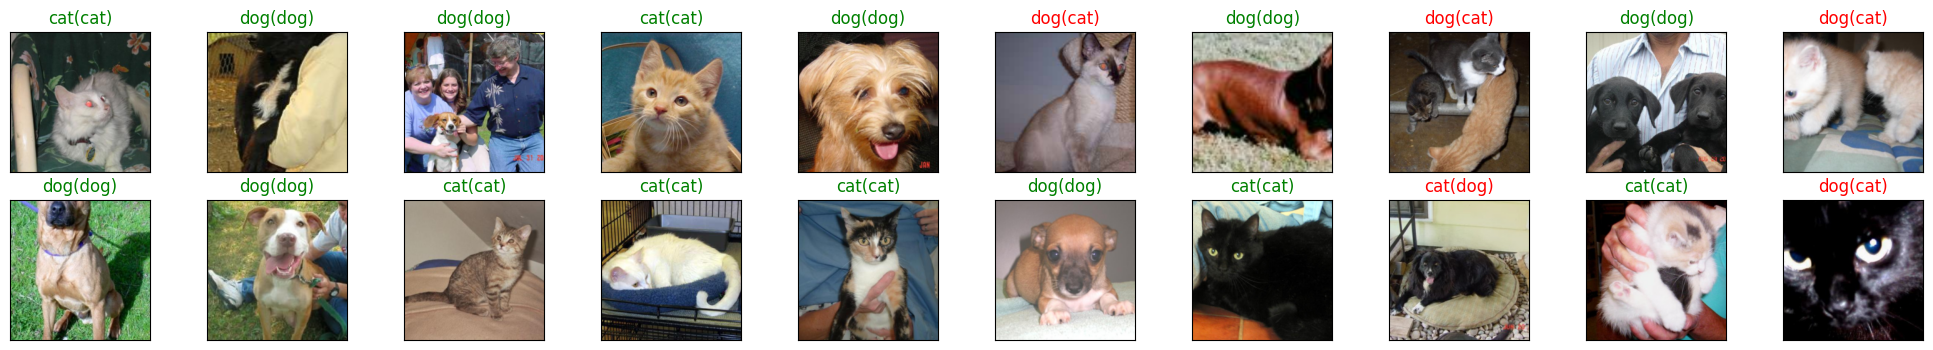

<Figure size 640x480 with 0 Axes>

In [ ]:
# 개와 고양이 예측 결과 출력
classes = {0:'cat', 1:'dog'}

dataiter=iter(test_loader)
images,labels=next(dataiter) # dataiter.next()에서 next(dataiter)로 수정
output=model(images)
_,preds=torch.max(output,1)

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
    plt.imshow(im_convert(images[idx]))
    a.set_title(classes[labels[i].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

- 초록: 예측 성공
- 빨강: 예측 실패 <br> 훈련 데이터를 늘리고, 에포크 횟수를 늘리면 결과 나아질 것.

## 5.4 설명 가능한 CNN

### 5.4.1 특성 맵 시각화

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 설명 가능한 네트워크 생성
- 13개의 합성곱층 + 2개의 FC층으로 구성
- 활성화 함수: ReLU


In [ ]:
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()

        # 특성 추출: 입력 이미지 → 고차원 특징 벡터로 변환
        # Conv + BatchNorm + ReLU + Dropout + MaxPool 반복
        # 채널: 3 → 64 → 128 → 256 → 512 → 512

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), # 기존 데이터를 연산의 결괏값으로 대체
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding = 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 이미지 분류기
        # 추출된 특징(512차원)을 실제 클래스 점수로 변환
        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x) # 특성 추출
        x = x.view(-1, 512) # flatten
        x = self.classifier(x) # 분류
        return F.log_softmax(x) # 기울기 소멸 문제 예방을 위해, 소프트맥스에 로그 취함

In [ ]:
# 모델 객체화 후 장치에 할당
model = XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

**특성 맵 시각화를 위한 함수 정의**
- 특성 맵: 입력 이미지와 필터 연산해서 얻은 결과
- 합성곱층에서 입출력을 알 수 있다면 특성 맵에 대한 값도 확인 가능

In [ ]:
# 특성 맵 확인하기 위한 클래스
class LayerActivations():
    features=[]
    def __init__(self, model, layer_num):
      self.hook = model[layer_num].register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
      self.features = output.detach().numpy()

    def remove(self):
      self.hook.remove()

`self.hook`: 파이토치에서 각 계층의 함수 및 기울기 값을 확인할 수 있는 기능. (매 계층마다 print문 사용 불필요) 파이토치는 특정 값으로 정의되지 않는 중간 변수에 대해서는 기울기값을 저장하지 않는데, hook을 사용하면 중간 변수에 대해서도 중간 결괏값을 알 수 있음.

In [ ]:
# 이미지 호출
from google.colab import files
uploaded = files.upload()

Saving cat.jpg to cat.jpg


torch.Size([1, 3, 100, 100])


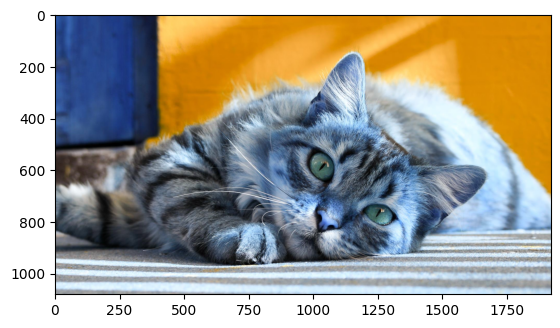

In [ ]:
img=cv2.imread("cat.jpg")
plt.imshow(img)

img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR) # 세 번째 파라미터: 보간법
img = ToTensor()(img).unsqueeze(0)

print(img.shape)

- `cv2.resize(img, (100,100), interpolation=cv2.INTER_LINEAR)` : 이미지 파일 img를 너비, 높이 100으로 지정하여 크기 변경. <br> 이미지 크기 변경 시, 이미지 비율을 변경하면 존재하지 않는 영역에 새로운 픽셀 값을 매핑하거나 존재하는 픽셀을 압축해 새로운 값을 할당해야 한다. 이를 방지하기 위해 이미지상에 존재하는 픽셀 데이터들에 대해 근사함수를 적용해 새 픽셀 값을 구하는 것을 '보간법'이라고 함.

- `ToTensor()(img).unsqueeze(0)`: 이미지 데이터를 텐서로 변환하고, 그 데이터를 1차원으로 변경. (unsqueeze: 1차원 데이터를 생성하는 함수)

**0번째** Conv2d 계층의 특성 맵

In [ ]:
# 0번째 Conv2d 특성 맵 확인
# (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
result = LayerActivations(model.features, 0)

model(img)
activations = result.features

/tmp/ipykernel_9724/1794002029.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x) # 기울기 소멸 문제 예방을 위해, 소프트맥스에 로그 취함


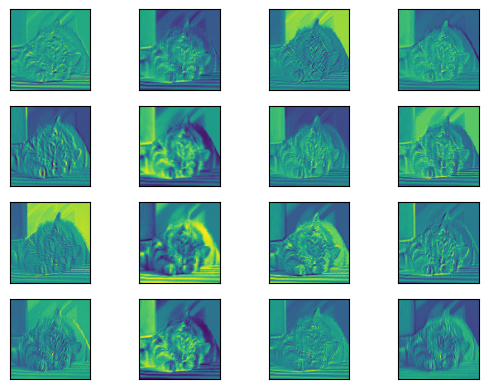

<Figure size 1200x800 with 0 Axes>

In [ ]:
# 특성 맵 시각적으로 확인
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

입력층과 가깝기 때문에 입력 이미지의 형태가 많이 유지되고 있음.

**20번째** Conv2d 계층의 특성 맵

In [ ]:
result = LayerActivations(model.features, 20)
model(img)
activations = result.features

/tmp/ipykernel_9724/1794002029.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x) # 기울기 소멸 문제 예방을 위해, 소프트맥스에 로그 취함


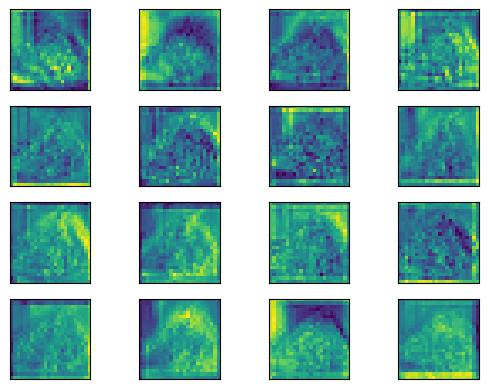

<Figure size 1200x800 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

20번째 특성 맵 결과, 기존 고양이 이미지의 형태는 보이지 않음.

**40번째** Conv2d 계층의 특성 맵

In [ ]:
result = LayerActivations(model.features, 40)
model(img)
activations = result.features

/tmp/ipykernel_9724/1794002029.py:75: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x) # 기울기 소멸 문제 예방을 위해, 소프트맥스에 로그 취함


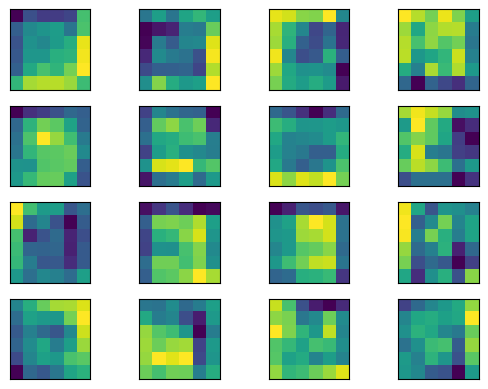

<Figure size 1200x800 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(4,4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
plt.show()

40번째 맵에서는 입력 이미지의 형태를 찾아볼 수 없게 됨. <br> 🌟 출력층에 가까울수록 기존 형태는 찾아볼 수 없고 **이미지 특징**들만 전달되는 것을 확인할 수 있음.